# 02 - Exploratory analysis

A look at the hourly series: overall shape, daily and weekly patterns, seasonal decomposition, autocorrelation, and stationarity tests. These decide the SARIMAX setup in notebook 04.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from appliance_energy import config, data, eda, plotting

config.ensure_dirs()
hourly = data.load_hourly_data()
y = hourly[config.TARGET]
y.shape

(3290,)

## Full-period view

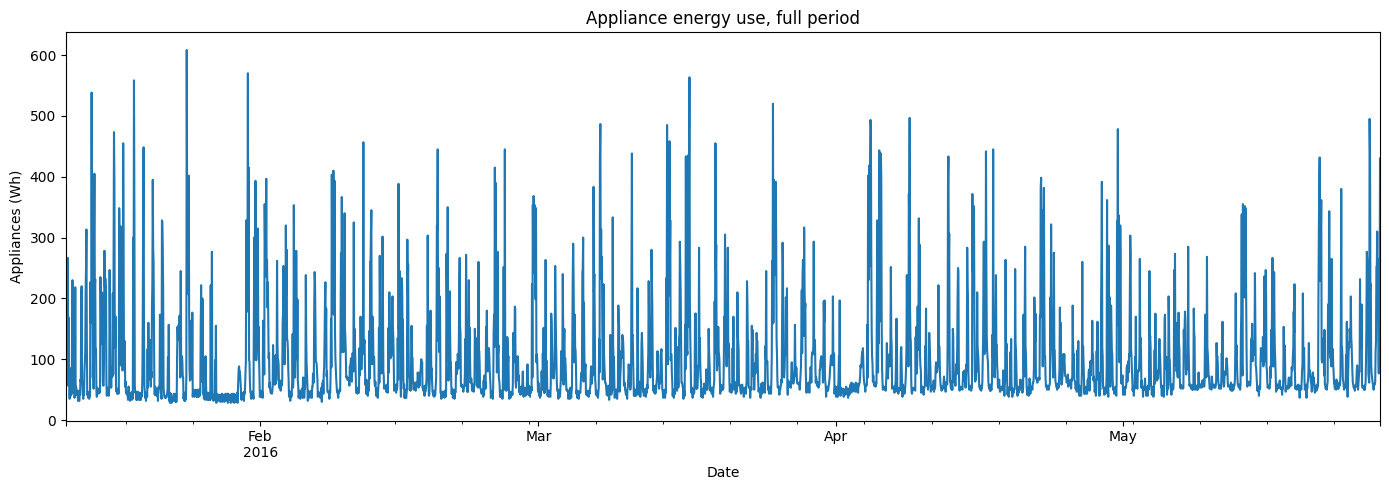

In [2]:
fig, ax = plotting.plot_time_series(
    y, title="Appliance energy use, full period", ylabel="Appliances (Wh)"
)
plt.show()

## Daily and weekly patterns

Two weeks is enough to see the daily cycle and the weekday/weekend split without any formal decomposition.

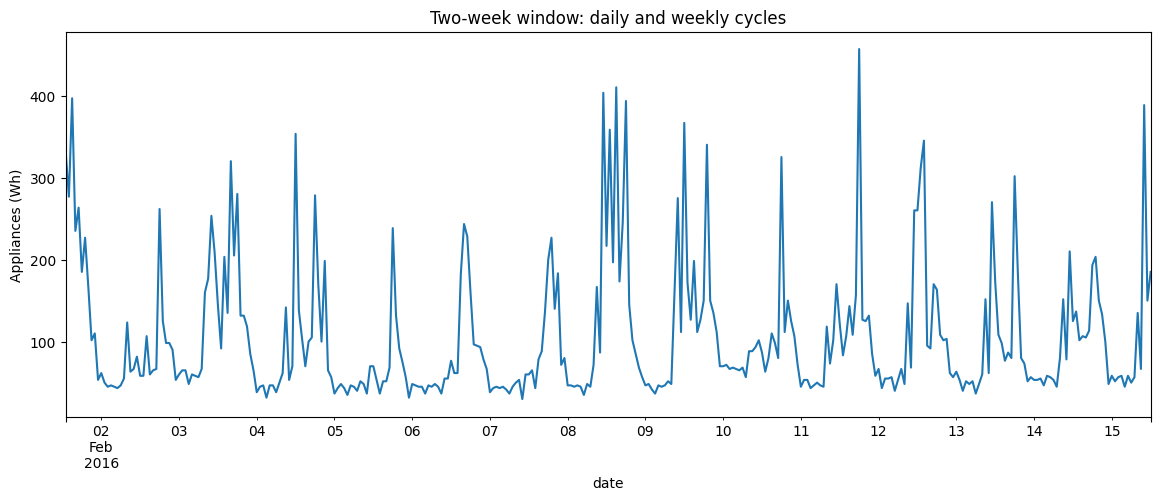

In [3]:
two_weeks = y.iloc[500:500 + 24 * 14]

fig, ax = plt.subplots(figsize=(14, 5))
two_weeks.plot(ax=ax)
ax.set_title("Two-week window: daily and weekly cycles")
ax.set_ylabel("Appliances (Wh)")
plt.show()

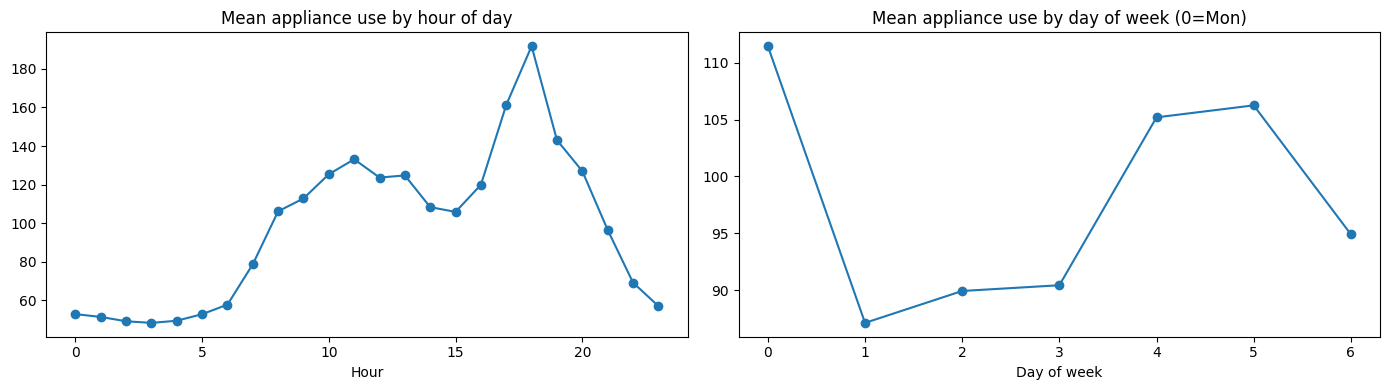

In [4]:
hourly_profile = y.groupby(y.index.hour).mean()
dow_profile = y.groupby(y.index.dayofweek).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
hourly_profile.plot(ax=axes[0], marker="o")
axes[0].set_title("Mean appliance use by hour of day")
axes[0].set_xlabel("Hour")

dow_profile.plot(ax=axes[1], marker="o")
axes[1].set_title("Mean appliance use by day of week (0=Mon)")
axes[1].set_xlabel("Day of week")
fig.tight_layout()
plt.show()

Both profiles show real structure. Use climbs through the day to an evening peak and runs a bit higher at weekends, so there's a strong **daily** cycle and a weaker **weekly** one.

## Seasonal decomposition (daily period = 24)

Saved figure to D:\UK ass\outputs\figures\02_seasonal_decomposition_daily.png


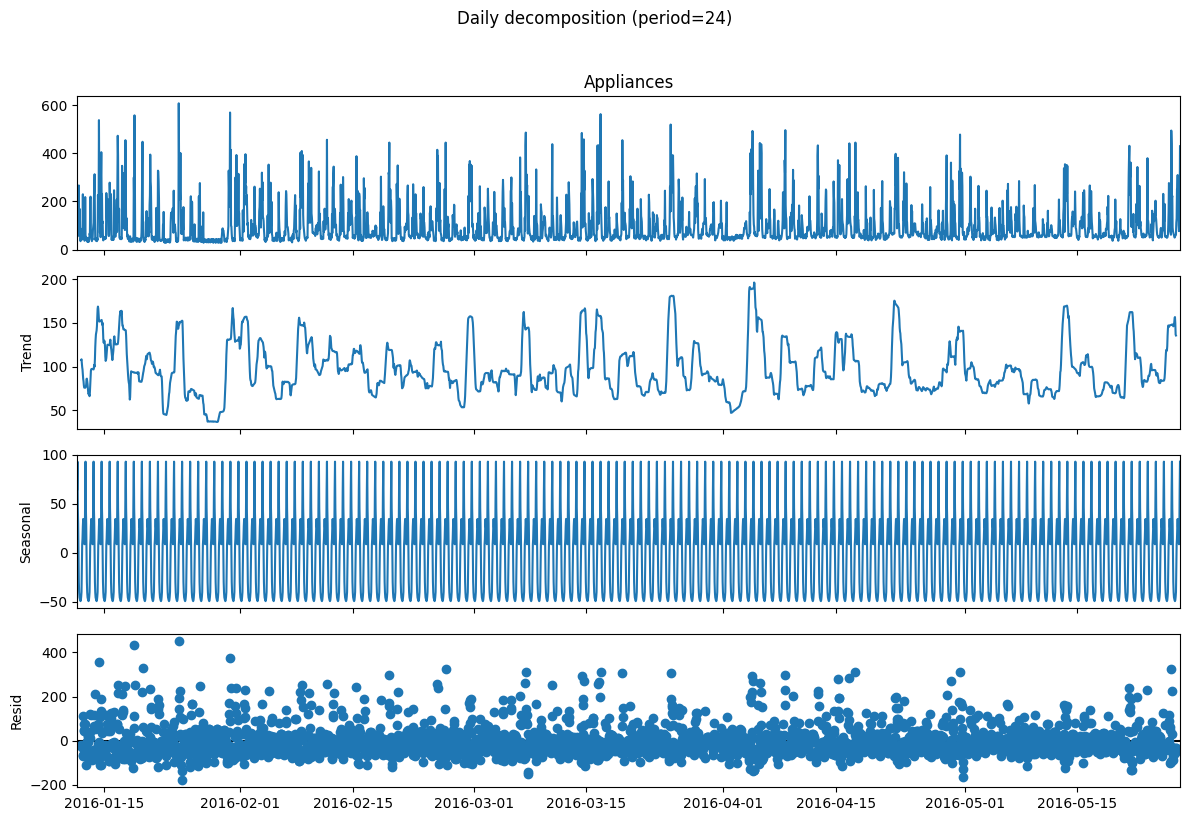

In [5]:
decomposition_daily = eda.decompose_series(y, period=config.DAILY_PERIOD, model="additive")
fig = plotting.plot_seasonal_decomposition(decomposition_daily, title="Daily decomposition (period=24)")
plotting.save_fig(fig, config.FIGURE_DIR / "02_seasonal_decomposition_daily.png")
plt.show()

## Autocorrelation structure (ACF / PACF)

Saved figure to D:\UK ass\outputs\figures\02_acf_pacf_level.png


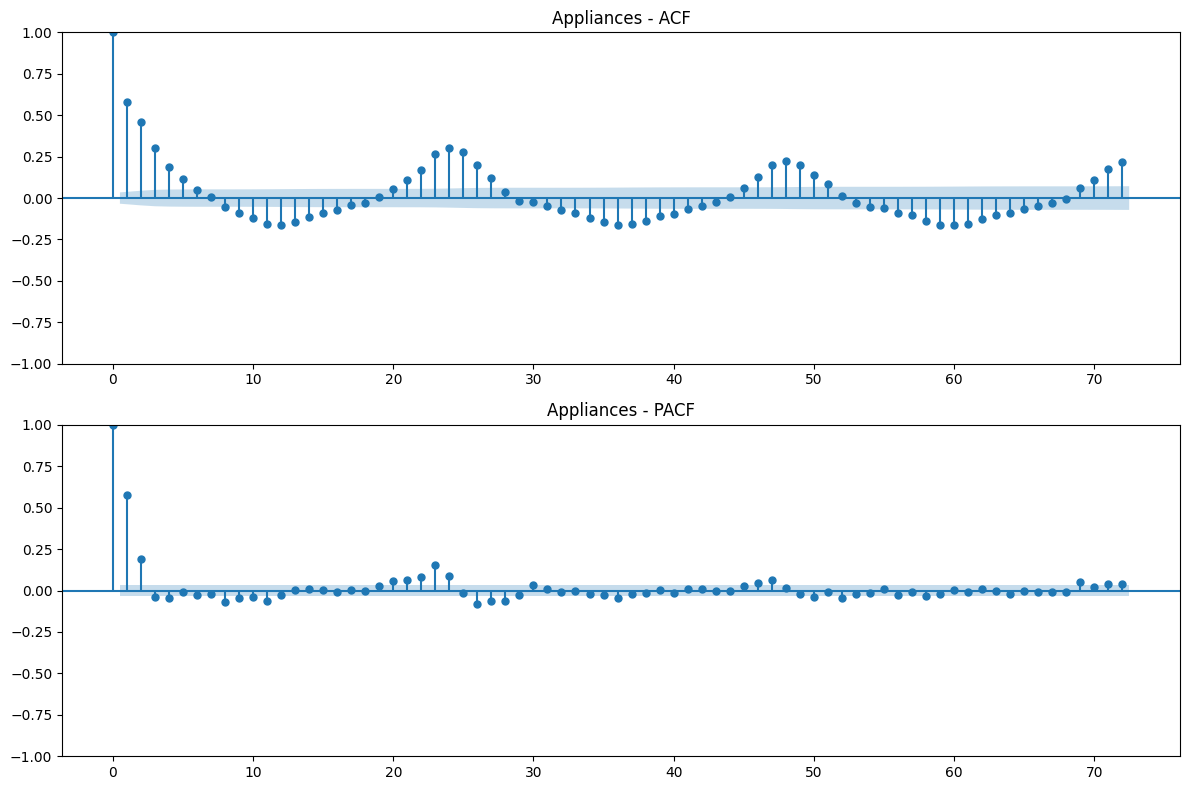

In [6]:
fig = plotting.plot_acf_pacf(y, lags=72, title_prefix="Appliances -")
plotting.save_fig(fig, config.FIGURE_DIR / "02_acf_pacf_level.png")
plt.show()

The ACF falls away slowly with clear spikes every 24 lags, which confirms the daily cycle. The smaller bump near lag 168 is the weekly one.

## Stationarity testing

We run the Augmented Dickey-Fuller (ADF) test on the raw series, the first difference, and the seasonal (lag-24) difference, the standard non-stationarity testing workflow (ADF, ACF/PACF, differencing).

In [7]:
eda.stationarity_report(y, seasonal_period=config.DAILY_PERIOD)

ADF test on 'level': statistic=-8.9489, p-value=0.0000 -> stationary at alpha=0.05


ADF test on 'first_difference': statistic=-16.9526, p-value=0.0000 -> stationary at alpha=0.05
ADF test on 'seasonal_difference_24': statistic=-13.5934, p-value=0.0000 -> stationary at alpha=0.05


,name,adf_statistic,p_value,used_lag,n_obs,is_stationary
0,level,-8.948888,8.833753e-15,29,3260,True
1,first_difference,-16.952574,9.437199e-30,29,3259,True
2,seasonal_difference_24,-13.593417,2.016273e-25,25,3240,True


## Interpretation

ADF rejects a unit root on the raw series (-8.95, p < 0.001), so `Appliances` is already stationary and needs no differencing to pass the test.

Stationary isn't the same as unstructured, though. The profiles, decomposition and ACF all show a strong daily cycle on top of a stationary series, and a non-seasonal model would miss it.

So notebook 04 uses SARIMAX with `seasonal_order=(..., 24)`: `d=0` because the level is already stationary, `D=1` for the daily cycle.

## ACF/PACF after seasonal differencing

Saved figure to D:\UK ass\outputs\figures\02_acf_pacf_seasonal_diff.png


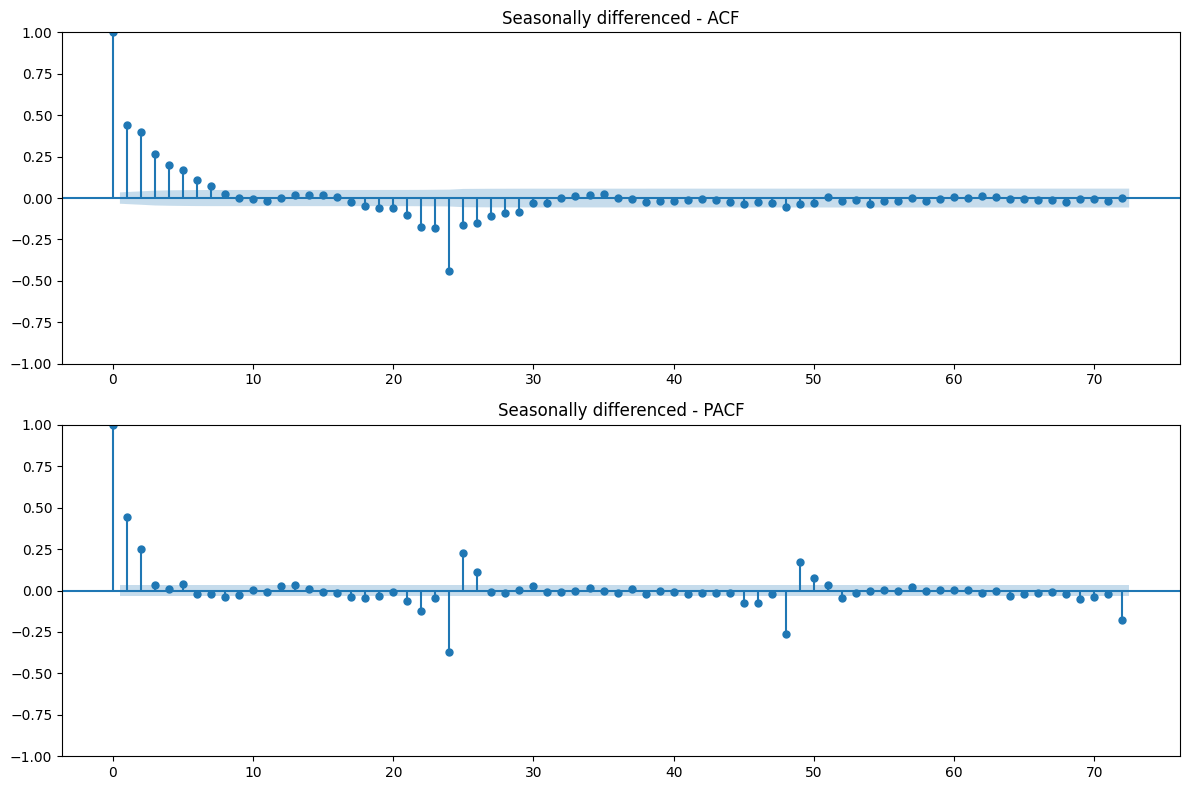

In [8]:
y_seasonal_diff = eda.difference_series(y, periods=config.DAILY_PERIOD)
fig = plotting.plot_acf_pacf(y_seasonal_diff, lags=72, title_prefix="Seasonally differenced -")
plotting.save_fig(fig, config.FIGURE_DIR / "02_acf_pacf_seasonal_diff.png")
plt.show()